In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator, DataGenerator
import guide_selection_coverage_analysis as gsca

Generation of Guides targeting top expressed RNA contigs
-

In [3]:
#import the read coverage from the concatenated bam files
#the non-standard chromosomes contain the ribosomal reads so do not remove them
cov = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/coverage_over_contigs', sep='\t', header=None, 
                 names=['Chrm', "Start", "Stop","#_Overlapped","Bases_non_0","Contig_length","Contig_Coverage"])
cov['Standard'] = list(
    map(lambda x: x.startswith('chr'), cov['Chrm'])) 

cov['Percent']= cov['#_Overlapped']/sum(cov['#_Overlapped'])
cov = cov.sort_values(by='Percent', ascending=False)
cov['cumsum'] = cov['Percent'].cumsum()
cov

,Chrm,Start,Stop,#_Overlapped,Bases_non_0,Contig_length,Contig_Coverage,Standard,Percent,cumsum
503136,chrM,0,16569,3130040,16569,16569,1.0,True,1.772161e-02,0.017722
111845,chr12,66057570,66057761,2117075,191,191,1.0,True,1.198642e-02,0.029708
174144,chr16,171759,173933,1137628,2174,2174,1.0,True,6.441003e-03,0.036149
174145,chr16,175039,177546,1077773,2507,2507,1.0,True,6.102117e-03,0.042251
432979,chr7,5527098,5531041,685492,3943,3943,1.0,True,3.881107e-03,0.046132
...,...,...,...,...,...,...,...,...,...,...
543802,KI270857.1,2081121,2081272,1,151,151,1.0,False,5.661783e-09,1.000000
176778,chr16,9676965,9677116,1,151,151,1.0,True,5.661783e-09,1.000000
309654,chr22,12495629,12495780,1,151,151,1.0,True,5.661783e-09,1.000000
250260,chr2,21796689,21796840,1,151,151,1.0,True,5.661783e-09,1.000000


In [4]:
cov_x = list(range(1,len(cov)+1,1))
cov_y = list(cov['cumsum'])

#find the knee bend in the data
#keep the sensitivity to 1.0, this affects where to select the knee bend
kneedle = KneeLocator(cov_x, cov_y, S=10, curve='concave', direction='increasing')
point_inflection = kneedle.knee
print('the point of knee inflection is = ', point_inflection)

#subset the database according to the intervals to the left of the knee inflection
cov_sub = cov.head(kneedle.knee-1)
cov_sub

the point of knee inflection is =  70167


,Chrm,Start,Stop,#_Overlapped,Bases_non_0,Contig_length,Contig_Coverage,Standard,Percent,cumsum
503136,chrM,0,16569,3130040,16569,16569,1.0,True,0.017722,0.017722
111845,chr12,66057570,66057761,2117075,191,191,1.0,True,0.011986,0.029708
174144,chr16,171759,173933,1137628,2174,2174,1.0,True,0.006441,0.036149
174145,chr16,175039,177546,1077773,2507,2507,1.0,True,0.006102,0.042251
432979,chr7,5527098,5531041,685492,3943,3943,1.0,True,0.003881,0.046132
...,...,...,...,...,...,...,...,...,...,...
182344,chr16,28565073,28565492,309,419,419,1.0,True,0.000002,0.839915
201006,chr17,29122165,29124520,309,2355,2355,1.0,True,0.000002,0.839917
110075,chr12,55988533,55988694,309,161,161,1.0,True,0.000002,0.839918
385336,chr5,74687037,74687236,309,199,199,1.0,True,0.000002,0.839920


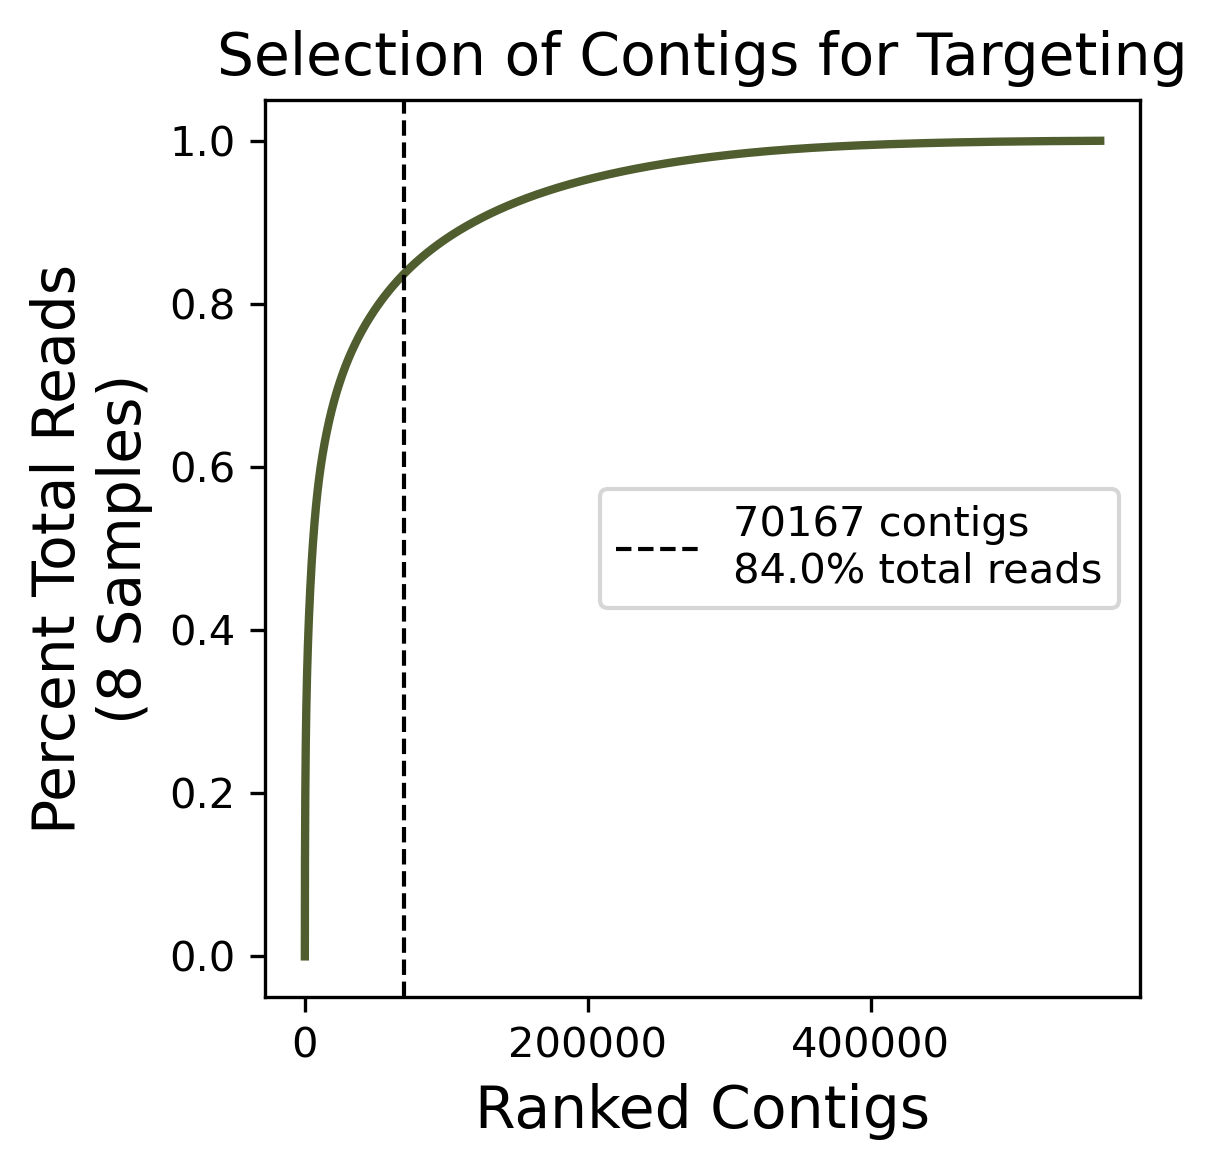

In [5]:
knee = str(kneedle.knee)
plt.figure(figsize=(4, 4), dpi=300)
plt.plot(kneedle.x, kneedle.y_normalized, color='#4F5D2F', linewidth=2)

percent_total = round(cov_sub.Percent.sum()*100,1)
plt.axvline(x = kneedle.knee, color = 'black', label = f'{knee} contigs \n{percent_total}% total reads',
           linestyle='--', linewidth=1)

plt.legend(loc='right')
plt.title('Selection of Contigs for Targeting', fontsize=14)
plt.xlabel('Ranked Contigs', fontsize=14)
plt.ylabel('Percent Total Reads\n(8 Samples)', fontsize=14)

plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_actual_samples_knee_bend.png', dpi=300)
plt.show()

Now generate quants over bins of targeted contigs 
-

In [6]:
#these are the selected contigs for targeting
contig = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/coverage_over_contigs_selected_70k_contigs.csv', sep='\t')

#generate new cumulative sum column in order to best seperate the bins
contig['new_cumsum'] = (contig['#_Overlapped']/sum(contig['#_Overlapped'])).cumsum()
contig

,Chrm,Start,Stop,#_Overlapped,Bases_non_0,Contig_length,Contig_Coverage,Standard,Percent,cumsum,new_cumsum
0,chrM,0,16569,3130040,16569,16569,1.0,True,0.017722,0.017722,0.021099
1,chr12,66057570,66057761,2117075,191,191,1.0,True,0.011986,0.029708,0.035370
2,chr16,171759,173933,1137628,2174,2174,1.0,True,0.006441,0.036149,0.043039
3,chr16,175039,177546,1077773,2507,2507,1.0,True,0.006102,0.042251,0.050304
4,chr7,5527098,5531041,685492,3943,3943,1.0,True,0.003881,0.046132,0.054924
...,...,...,...,...,...,...,...,...,...,...,...
70161,chr16,28565073,28565492,309,419,419,1.0,True,0.000002,0.839915,0.999992
70162,chr17,29122165,29124520,309,2355,2355,1.0,True,0.000002,0.839917,0.999994
70163,chr12,55988533,55988694,309,161,161,1.0,True,0.000002,0.839918,0.999996
70164,chr5,74687037,74687236,309,199,199,1.0,True,0.000002,0.839920,0.999998


In [7]:
#assign to different bins 
bin_thresholds = [0, 0.25, 0.4, 0.55, 0.68, 0.77, 0.85, 0.93, 1]

def determine_bin(cumsum_value):
    for i in range(len(bin_thresholds) - 1):
        if bin_thresholds[i] <= cumsum_value < bin_thresholds[i + 1]:
            return i + 1
    return len(bin_thresholds) - 1  

contig['Bin'] = contig['new_cumsum'].apply(determine_bin)
contig['Bin'].value_counts()

Bin
8    26448
7    18111
6    10437
5     6635
4     4674
3     2597
2      953
1      311
Name: count, dtype: int64

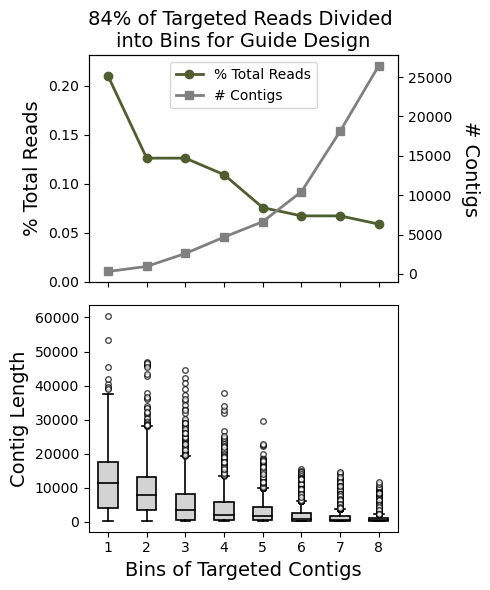

In [8]:
# Aggregate by Bin
g = contig.groupby("Bin", dropna=False)
bins = sorted([b for b in g.size().index if pd.notna(b)])
percent_sum = g["Percent"].sum().reindex(bins).fillna(0).values
contig_count = g.size().reindex(bins).values
lengths_by_bin = [contig.loc[contig["Bin"] == b, "Contig_length"].dropna().values for b in bins]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(5, 6), sharex=True, gridspec_kw={"height_ratios":[1,1]})

# --- Top: dual-y line plot ---
l1 = ax_top.plot(bins, percent_sum, marker="o", linewidth=2, label="% Total Reads", color="#4F5D2F")
ax_top.set_ylabel("% Total Reads", fontsize=14)
ax_top.set_title("84% of Targeted Reads Divided \ninto Bins for Guide Design", fontsize=14)
ax_top.set_xlim(min(bins)-0.5, max(bins)+0.5)
ax_top.set_ylim(0, max(percent_sum)*1.1)

axr = ax_top.twinx()
l2 = axr.plot(bins, contig_count, marker="s", linewidth=2, linestyle="-", label="# Contigs", color="grey")
axr.set_ylabel("# Contigs", fontsize=14, rotation=-90, labelpad=20)

# Combined legend
lines = l1 + l2
labels = [ln.get_label() for ln in lines]
ax_top.legend(lines, labels, loc="upper center")

# --- Bottom: boxplot (light grey) ---
bp = ax_bot.boxplot(lengths_by_bin, patch_artist=True)
for box in bp['boxes']:
    box.set(facecolor="lightgray", edgecolor="black", linewidth=1.2)
for part in ('whiskers','caps','medians','fliers'):
    for artist in bp[part]:
        if part == 'fliers':
            artist.set(marker='o', markersize=4, markerfacecolor='white', markeredgecolor='black', alpha=0.7)
        else:
            artist.set(color="black", linewidth=1.2)

ax_bot.set_xlabel("Bins of Targeted Contigs", fontsize=14)
ax_bot.set_ylabel("Contig Length", fontsize=14)
ax_bot.set_xticks(range(1, len(bins)+1))
ax_bot.set_xticklabels([str(b) for b in bins])

plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_targeting_bins.png', dpi=300)
plt.show()

Guide density per bin - distirbution
-

In [9]:
#read in the selected guides with 0 offtarget hits on the DO NOT HIT list
selected = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/selected_guides_no_OFF_target_hits_3million.csv', header=0)

#remove the polyT regions because these lead to poor IVT production of the guides, homopolymers are bad
def remove_rows_with_sequence(df, column, sequence):
    return df[~df[column].str.contains(sequence)]

selected_filtered = remove_rows_with_sequence(selected, 'target', 'T' * 5)
selected_filtered = remove_rows_with_sequence(selected, 'target', 'A' * 7)
selected_filtered = remove_rows_with_sequence(selected, 'target', 'C' * 7)
selected_filtered = remove_rows_with_sequence(selected, 'target', 'G' * 7)
selected_filtered

,index,contig,start,stop,target,context,overflow,orientation,otCount,off_target_hits
0,chr1:186335067-186335550_0_23_ATTCCTCTTTCACCAG...,chr1:186335067-186335550,0,23,ATTCCTCTTTCACCAGAAGCTGG,NONE,OK,FWD,3,0
1,chr1:119928729-119930781_0_23_TGATTATATCATGCTA...,chr1:119928729-119930781,0,23,TGATTATATCATGCTATGGCAGG,NONE,OK,RVS,1,0
2,chr1:35617353-35617528_0_23_TAGCCAAGAGGATTAAAG...,chr1:35617353-35617528,0,23,TAGCCAAGAGGATTAAAGTCAGG,NONE,OK,RVS,2,0
3,chr1:53152-53302_0_23_ATGTTAGATCACATCACAGTAGG,chr1:53152-53302,0,23,ATGTTAGATCACATCACAGTAGG,NONE,OK,FWD,1,0
4,chr1:167646764-167647915_0_23_CGAGGATCCTATTTCT...,chr1:167646764-167647915,0,23,CGAGGATCCTATTTCTCTTGAGG,NONE,OK,RVS,1,0
...,...,...,...,...,...,...,...,...,...,...
3686411,chrX:154396038-154421908_25797_25820_TTAAGTGAC...,chrX:154396038-154421908,25797,25820,TTAAGTGACTGGTGCAGAAGAGG,AACTGAAGCCTTAAGTGACTGGTGCAGAAGAGGTTGATGCCCA,OK,RVS,1,0
3686412,chrX:154396038-154421908_25799_25822_TCTTCTGCA...,chrX:154396038-154421908,25799,25822,TCTTCTGCACCAGTCACTTAAGG,GGCATCAACCTCTTCTGCACCAGTCACTTAAGGCTTCAGTTAT,OK,FWD,1,0
3686413,chrX:154396038-154421908_25808_25831_TAACTGAAG...,chrX:154396038-154421908,25808,25831,TAACTGAAGCCTTAAGTGACTGG,TTACAGACAATAACTGAAGCCTTAAGTGACTGGTGCAGAAGAG,OK,RVS,2,0
3686414,chrX:154396038-154421908_25842_25865_ATTTCTGCA...,chrX:154396038-154421908,25842,25865,ATTTCTGCAATGTTGTTACAGGG,NONE,OK,RVS,1,0


In [10]:
#add the bin information to the selected guides
guides = selected_filtered.set_index('contig')
contig['contig'] = contig['Chrm']+':'+contig['Start'].astype(str)+'-'+contig['Stop'].astype(str)
contig = contig.set_index('contig')
guides['Bin'] = contig['Bin']
guides = guides.reset_index(drop=False)
guides

,contig,index,start,stop,target,context,overflow,orientation,otCount,off_target_hits,Bin
0,chr1:186335067-186335550,chr1:186335067-186335550_0_23_ATTCCTCTTTCACCAG...,0,23,ATTCCTCTTTCACCAGAAGCTGG,NONE,OK,FWD,3,0,7
1,chr1:119928729-119930781,chr1:119928729-119930781_0_23_TGATTATATCATGCTA...,0,23,TGATTATATCATGCTATGGCAGG,NONE,OK,RVS,1,0,8
2,chr1:35617353-35617528,chr1:35617353-35617528_0_23_TAGCCAAGAGGATTAAAG...,0,23,TAGCCAAGAGGATTAAAGTCAGG,NONE,OK,RVS,2,0,8
3,chr1:53152-53302,chr1:53152-53302_0_23_ATGTTAGATCACATCACAGTAGG,0,23,ATGTTAGATCACATCACAGTAGG,NONE,OK,FWD,1,0,6
4,chr1:167646764-167647915,chr1:167646764-167647915_0_23_CGAGGATCCTATTTCT...,0,23,CGAGGATCCTATTTCTCTTGAGG,NONE,OK,RVS,1,0,7
...,...,...,...,...,...,...,...,...,...,...,...
3682388,chrX:154396038-154421908,chrX:154396038-154421908_25797_25820_TTAAGTGAC...,25797,25820,TTAAGTGACTGGTGCAGAAGAGG,AACTGAAGCCTTAAGTGACTGGTGCAGAAGAGGTTGATGCCCA,OK,RVS,1,0,1
3682389,chrX:154396038-154421908,chrX:154396038-154421908_25799_25822_TCTTCTGCA...,25799,25822,TCTTCTGCACCAGTCACTTAAGG,GGCATCAACCTCTTCTGCACCAGTCACTTAAGGCTTCAGTTAT,OK,FWD,1,0,1
3682390,chrX:154396038-154421908,chrX:154396038-154421908_25808_25831_TAACTGAAG...,25808,25831,TAACTGAAGCCTTAAGTGACTGG,TTACAGACAATAACTGAAGCCTTAAGTGACTGGTGCAGAAGAG,OK,RVS,2,0,1
3682391,chrX:154396038-154421908,chrX:154396038-154421908_25842_25865_ATTTCTGCA...,25842,25865,ATTTCTGCAATGTTGTTACAGGG,NONE,OK,RVS,1,0,1


In [11]:
#input the scoring results and then assignt the proper metadata 
scored = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/GUIDES_3m_selection_design_0_offtargets.output.scored', sep='\t')

#add the bin information, custom scoring metric 
guides = guides.set_index('index')
scored['index'] = scored['contig']+'_'+scored['start'].astype(str)+'_'+scored['stop'].astype(str)+'_'+scored['target']
scored = scored.set_index('index')
scored['Bin'] = guides['Bin']
scored['otCount'] = guides['otCount']
scored['score'] = (scored['Doench2014OnTarget'] + scored['Moreno-Mateos2015OnTarget'])/2
scored['score'] = scored['score'].fillna(0)

#remove rows with PolyT and with dangerous GC content from the Flashfry metrics
scored = scored[scored['dangerous_polyT']=='NONE']
scored = scored[scored['dangerous_GC']=='NONE']
scored

,contig,start,stop,target,context,overflow,orientation,Doench2014OnTarget,Moreno-Mateos2015OnTarget,dangerous_GC,dangerous_polyT,dangerous_in_genome,otCount,Bin,score
index,,,,,,,,,,,,,,,
chr1:119928729-119930781_0_23_TGATTATATCATGCTATGGCAGG,chr1:119928729-119930781,0,23,TGATTATATCATGCTATGGCAGG,NONE,OK,RVS,NaN,NaN,NONE,NONE,NONE,1,8,0.000000
chr1:35617353-35617528_0_23_TAGCCAAGAGGATTAAAGTCAGG,chr1:35617353-35617528,0,23,TAGCCAAGAGGATTAAAGTCAGG,NONE,OK,RVS,NaN,NaN,NONE,NONE,NONE,2,8,0.000000
chr1:53152-53302_0_23_ATGTTAGATCACATCACAGTAGG,chr1:53152-53302,0,23,ATGTTAGATCACATCACAGTAGG,NONE,OK,FWD,NaN,NaN,NONE,NONE,NONE,1,6,0.000000
chr1:167646764-167647915_0_23_CGAGGATCCTATTTCTCTTGAGG,chr1:167646764-167647915,0,23,CGAGGATCCTATTTCTCTTGAGG,NONE,OK,RVS,NaN,NaN,NONE,NONE,NONE,1,7,0.000000
chr1:2305914-2306266_0_23_TTGTCAGATAGATGACCCCACGG,chr1:2305914-2306266,0,23,TTGTCAGATAGATGACCCCACGG,NONE,OK,FWD,NaN,NaN,NONE,NONE,NONE,1,6,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr22:42396440-42433181_36669_36692_ACTTCTAGCAGCATCAGCCGGGG,chr22:42396440-42433181,36669,36692,ACTTCTAGCAGCATCAGCCGGGG,CCCTGCTCTCACTTCTAGCAGCATCAGCCGGGGACAGGAATTG,OK,FWD,0.787812,0.194416,NONE,NONE,NONE,3,2,0.491114
chr22:42396440-42433181_36674_36697_TAGCAGCATCAGCCGGGGACAGG,chr22:42396440-42433181,36674,36697,TAGCAGCATCAGCCGGGGACAGG,CTCTCACTTCTAGCAGCATCAGCCGGGGACAGGAATTGTTTGC,OK,FWD,0.026507,0.873092,NONE,NONE,NONE,1,2,0.449800
chr22:42396440-42433181_36686_36709_CAGCAAACAATTCCTGTCCCCGG,chr22:42396440-42433181,36686,36709,CAGCAAACAATTCCTGTCCCCGG,GGGGTCCCGGCAGCAAACAATTCCTGTCCCCGGCTGATGCTGC,OK,RVS,0.277476,0.491591,NONE,NONE,NONE,1,2,0.384533


In [ ]:
#array1 selection and analysis
array_1 = gsca.select_sliding_window_guides(scored, 1, window_size=50)
supp_array_1 = gsca.supplement_guides_with_repeat_hits(scored, array_1, 1)
guide_density_supp_array1 = gsca.calculate_guide_density_over_contig(supp_array_1)

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
#array2 
array_2 = gsca.select_sliding_window_guides(scored, 2, window_size=100)
supp_array_2 = gsca.supplement_guides_with_repeat_hits(scored, array_2, 2)
guide_density_supp_array2 = gsca.calculate_guide_density_over_contig(supp_array_2)

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
#array3 
array_3 = gsca.select_sliding_window_guides(scored, 3, window_size=150)
total_guides_repeats = len(array_3) - len(array_3['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_3 = gsca.supplement_guides_with_repeat_hits(scored, array_3, 3, total_guides=total_guides_repeats)
guide_density_supp_array3 = gsca.calculate_guide_density_over_contig(supp_array_3)

65300


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
array_4 = gsca.select_sliding_window_guides(scored, 4, window_size=200)
total_guides_repeats = len(array_4) - len(array_4['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_4 = gsca.supplement_guides_with_repeat_hits(scored, array_4, 4, total_guides=total_guides_repeats)
guide_density_supp_array4 = gsca.calculate_guide_density_over_contig(supp_array_4)

64061


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
array_5 = gsca.select_sliding_window_guides(scored, 5, window_size=235)
total_guides_repeats = len(array_5) - len(array_5['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_5 = gsca.supplement_guides_with_repeat_hits(scored, array_5, 5, total_guides=total_guides_repeats)
guide_density_supp_array5 = gsca.calculate_guide_density_over_contig(supp_array_5)

63405


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
array_6 = gsca.select_sliding_window_guides(scored, 6, window_size=250)
total_guides_repeats = len(array_6) - len(array_6['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_6 = gsca.supplement_guides_with_repeat_hits(scored, array_6, 6, total_guides=total_guides_repeats)
guide_density_supp_array6 = gsca.calculate_guide_density_over_contig(supp_array_6)

63096


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
array_7 = gsca.select_sliding_window_guides(scored, 7, window_size=325)
total_guides_repeats = len(array_7) - len(array_7['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_7 = gsca.supplement_guides_with_repeat_hits(scored, array_7, 7, total_guides=total_guides_repeats)
guide_density_supp_array7 = gsca.calculate_guide_density_over_contig(supp_array_7)

62566


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [ ]:
array_8 = gsca.select_sliding_window_guides(scored, 8, window_size=350)
total_guides_repeats = len(array_8) - len(array_8['target'].unique()) + 60000
print(total_guides_repeats)
supp_array_8 = gsca.supplement_guides_with_repeat_hits(scored, array_8, 8, total_guides=total_guides_repeats)
guide_density_supp_array8 = gsca.calculate_guide_density_over_contig(supp_array_8)

62219


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_98450/126848880.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  density_df = df.groupby('contig').apply(lambda x: len(x) / (x['contig_length'].iloc[0] / 100)).reset_index()


In [335]:
guide_density_supp_array1['bin'] = 1
guide_density_supp_array2['bin'] = 2
guide_density_supp_array3['bin'] = 3
guide_density_supp_array4['bin'] = 4
guide_density_supp_array5['bin'] = 5
guide_density_supp_array6['bin'] = 6
guide_density_supp_array7['bin'] = 7
guide_density_supp_array8['bin'] = 8
combined = pd.concat([guide_density_supp_array1, guide_density_supp_array2, guide_density_supp_array3, guide_density_supp_array4,
                      guide_density_supp_array5, guide_density_supp_array6, guide_density_supp_array7, guide_density_supp_array8], ignore_index=True)
combined

,contig,guide_density,bin
0,GL000220.1:105111-118971,5.692641,1
1,GL000220.1:149083-161802,5.841654,1
2,KI270733.1:121960-140040,5.138274,1
3,KI270733.1:167042-179772,5.875884,1
4,KI270745.1:4-34462,0.272796,1
...,...,...,...
55282,chrY:2218207-2221765,0.309162,8
55283,chrY:24362021-24362435,0.483092,8
55284,chrY:333046-337963,0.549115,8
55285,chrY:7329057-7335428,0.455188,8


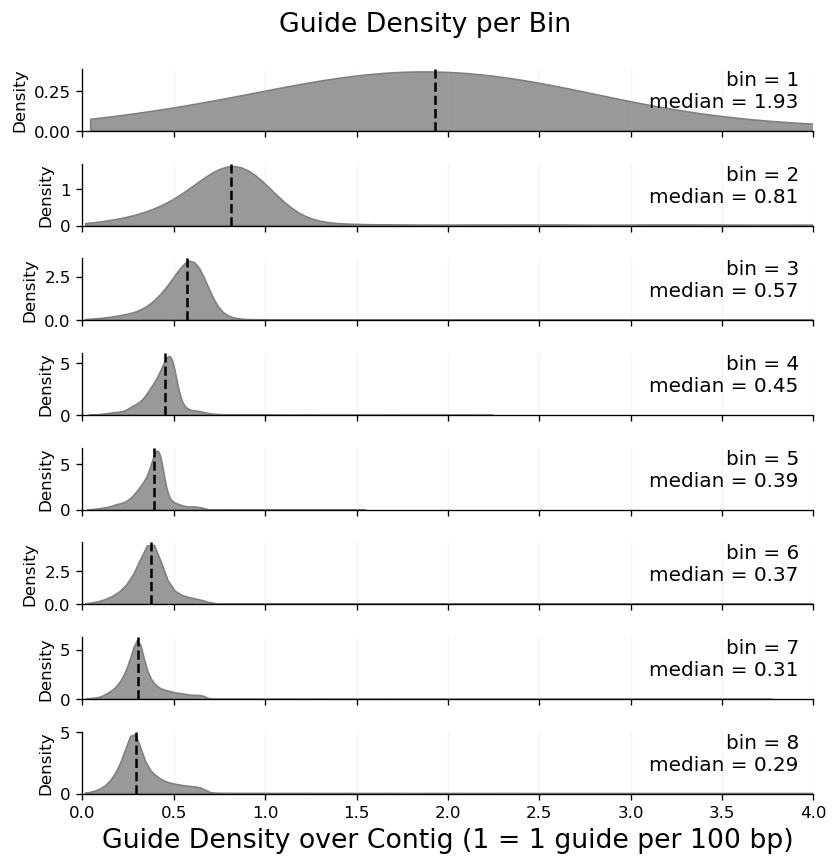

In [ ]:
bin_order = sorted(combined['bin'].unique())
med = combined.groupby('bin')['guide_density'].median()

fig, axes = plt.subplots(
    nrows=len(bin_order), ncols=1, sharex=True,
    figsize=(7, 0.9*len(bin_order)), dpi=120
)

if len(bin_order) == 1:
    axes = [axes]

for ax, b in zip(axes, bin_order):
    dfb = combined[combined['bin'] == b]
    sns.kdeplot(data=dfb, x='guide_density', fill=True, alpha=0.8, color='grey', common_norm=True, ax=ax, cut=0)
    ax.axvline(med.loc[b], linestyle='--', linewidth=1.5, color='black', label='Median')
    ax.set_xlim(0,4)
    ax.text(
        0.98, 0.98, f'bin = {b}\nmedian = {med.loc[b]:.2f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, 
    )
    sns.despine(ax=ax)
    ax.set_ylabel('Density')
    ax.grid(axis='x', alpha=0.15)

axes[-1].set_xlabel('Guide Density over Contig (1 = 1 guide per 100 bp)', fontsize=16)
fig.suptitle('Guide Density per Bin', y=0.995, fontsize=16)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_guide_density_per_bin_supplemented_arrays.png', dpi=300)
plt.show()

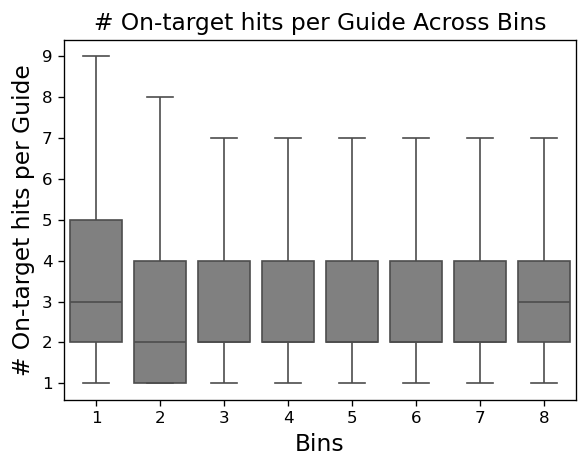

In [ ]:
combined = pd.concat([supp_array_1, supp_array_2, supp_array_3, supp_array_4,
                      supp_array_5, supp_array_6, supp_array_7, supp_array_8], ignore_index=True
                      )

#plot a boxplot of the otcount, with bins on the x axis
plt.figure(figsize=(5, 4), dpi=120)
sns.boxplot(data=combined, x='bin', y='otCount', color='gray', showfliers=False)
plt.title('# On-target hits per Guide Across Bins', fontsize=14)
plt.xlabel('Bins', fontsize=14)
plt.ylabel('# On-target hits per Guide', fontsize=14)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_ontarget_hits_per_guide_across_bins_supplemented_arrays.pdf', dpi=300)
plt.show()

Now use the in-silico depletion workflow to get an understanding of how genes were effected 
-
assuming there is a 100% removal of all targeted RNA - how does this affect genes and other genomic features?

In [197]:
#control RSEM TPM outs 
control = pd.read_csv('GREGOR_GUIDE/RSEM_Control_.genes.results', sep='\t', header=0)
#depleted RSEM TPM outs 
depleted = pd.read_csv('GREGOR_GUIDE/RSEM_Depleted_.genes.results', sep='\t', header=0)
merged = control[['gene_id', 'TPM']].merge(
    depleted[['gene_id', 'TPM']], on='gene_id', suffixes=('_control', '_depleted')
)
merged = merged[(merged['TPM_control'] > 0) | (merged['TPM_depleted'] > 0)]
merged['difference'] = merged['TPM_depleted'] - merged['TPM_control']

def conditions(s):
    if (s['TPM_control'] == 0):
        return 'TPM = 0'
    elif (s['TPM_control'] > 0)&(s['TPM_control'] < 1):
        return '0 < TPM < 1'
    elif (s['TPM_control'] > 1)&(s['TPM_control'] < 10):
        return '1 < TPM < 10'
    elif (s['TPM_control'] > 10)&(s['TPM_control'] < 100):
        return '10 < TPM < 100'
    elif (s['TPM_control'] > 100)&(s['TPM_control'] < 1000):
        return '100 < TPM < 1000'
    elif (s['TPM_control'] >= 1000):
        return 'TPM ≥ 1000'
merged['Standard_Bins'] = merged.apply(conditions, axis=1)

def conditions(s):
    if (s['difference'] > 0):
        return 'Enriched'
    elif (s['difference'] < 0):
        return 'Depleted'
merged['Condition'] = merged.apply(conditions, axis=1)
merged

,gene_id,TPM_control,TPM_depleted,difference,Standard_Bins,Condition
0,ENSG00000000003.15,0.00,0.96,0.96,TPM = 0,Enriched
2,ENSG00000000419.13,6.27,122.24,115.97,1 < TPM < 10,Enriched
3,ENSG00000000457.14,0.98,32.22,31.24,0 < TPM < 1,Enriched
4,ENSG00000000460.17,0.53,5.62,5.09,0 < TPM < 1,Enriched
5,ENSG00000000938.13,88.47,359.28,270.81,10 < TPM < 100,Enriched
...,...,...,...,...,...,...
60697,ENSG00000288626.1,0.00,0.06,0.06,TPM = 0,Enriched
60700,ENSG00000288630.1,0.34,0.68,0.34,0 < TPM < 1,Enriched
60702,ENSG00000288632.1,0.29,0.00,-0.29,0 < TPM < 1,Depleted
60704,ENSG00000288634.1,0.00,136.65,136.65,TPM = 0,Enriched


In [217]:
enriched = pd.DataFrame(merged[merged['Condition']=='Enriched'].Standard_Bins.value_counts()).reset_index()
depleted = pd.DataFrame(merged[merged['Condition']=='Depleted'].Standard_Bins.value_counts()).reset_index()
enriched = enriched.set_index('Standard_Bins')
depleted = depleted.set_index('Standard_Bins')
enriched['depleted_counts'] = depleted['count']
enriched = enriched.fillna(0)
enriched['proportion_depleted'] = enriched['depleted_counts']/(enriched['count']+enriched['depleted_counts'])
enriched['proportion_enriched'] = enriched['count']/(enriched['count']+enriched['depleted_counts'])
enriched = enriched.sort_values(by='proportion_depleted', ascending=True)
enriched = enriched.drop(columns=['depleted_counts','count'])
enriched['bins']=enriched.index
enriched

,proportion_depleted,proportion_enriched,bins
Standard_Bins,,,
TPM = 0,0.000000,1.000000,TPM = 0
0 < TPM < 1,0.077571,0.922429,0 < TPM < 1
1 < TPM < 10,0.092830,0.907170,1 < TPM < 10
10 < TPM < 100,0.159712,0.840288,10 < TPM < 100
100 < TPM < 1000,0.435540,0.564460,100 < TPM < 1000
TPM ≥ 1000,0.761905,0.238095,TPM ≥ 1000


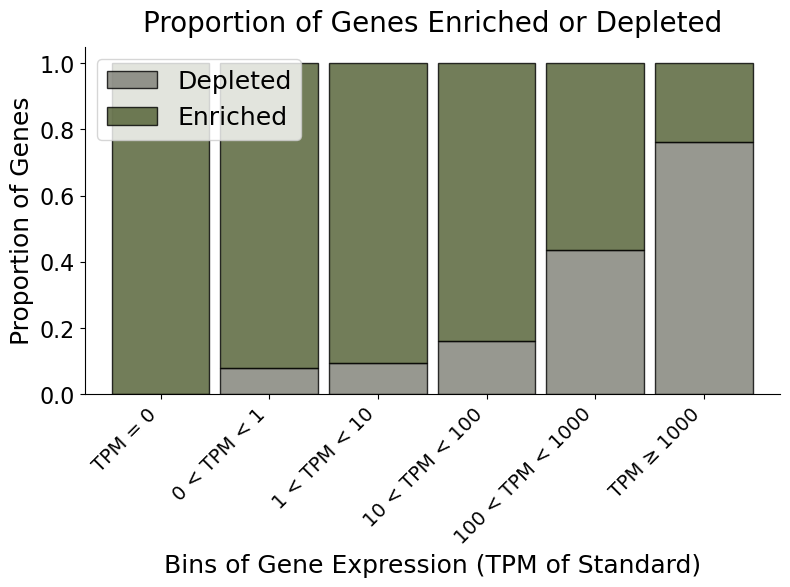

In [237]:
ax = enriched.plot.bar(x='bins', stacked=True, color=['#7D7E75', '#4F5D2F'], figsize=(8,6),
                      rot=45, legend='right', xlabel="", fontsize=16, width=0.9, alpha=0.8, edgecolor='black')
ax.set_title('Proportion of Genes Enriched or Depleted', fontsize=20, y=1.02)
ax.set_ylabel('Proportion of Genes',fontsize=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

ax.set_xticks(ax.get_xticks(), labels=enriched['bins'], fontsize=14)
ax.legend(['Depleted', 'Enriched'], loc='upper left', fontsize=18)
sns.despine()
plt.xlabel('Bins of Gene Expression (TPM of Standard)', fontsize=18)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_proportion_genes_enriched_depleted_per_TPM_bin.pdf', dpi=300)
plt.show()

How about just overlapping the targeted contigs with gene annotations 
-

In [343]:
targeted = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Targeted_gene_list_10k.csv')
targeted = targeted['Gene'].tolist()

In [344]:
control = pd.read_csv('GREGOR_GUIDE/RSEM_Control_.genes.results', sep='\t', header=0)
conversion = pd.read_csv('GREGOR_GUIDE/Conversion_Table_Ensemble_ID_to_Gene_name.csv')
conversion = conversion.set_index('Ensembl')

refined_gene = []
gene_num = list(control['gene_id'])
for gene in gene_num:
    ensg,number = gene.split('.')
    refined_gene.append(ensg)
control['gene']=refined_gene
control.set_index('gene', inplace=True)

#reduce all gene names down to the amount found experimentally
gene_conv_sub = conversion[conversion.index.isin(list(control.index))]
control['gene_name'] = gene_conv_sub['Gene_name']

In [345]:
def conditions(s):
    if (s['TPM'] == 0):
        return 'TPM = 0'
    elif (s['TPM'] > 0)&(s['TPM'] < 1):
        return '0 < TPM < 1'
    elif (s['TPM'] > 1)&(s['TPM'] < 10):
        return '1 < TPM < 10'
    elif (s['TPM'] > 10)&(s['TPM'] < 100):
        return '10 < TPM < 100'
    elif (s['TPM'] > 100)&(s['TPM'] < 1000):
        return '100 < TPM < 1000'
    elif (s['TPM'] >= 1000):
        return 'TPM ≥ 1000'
control['Standard_Bins'] = control.apply(conditions, axis=1)

In [346]:
#if gene name is in targeted list then 'Depleted' else 'Enriched'
control['Condition'] = control['gene_name'].apply(lambda x: 'Depleted' if x in targeted else 'Enriched')
control

,gene_id,transcript_id(s),length,effective_length,expected_count,TPM,FPKM,gene_name,Standard_Bins,Condition
gene,,,,,,,,,,
ENSG00000000003,ENSG00000000003.15,"ENST00000373020.9,ENST00000494424.1,ENST000004...",2061.80,1911.80,0.0,0.00,0.00,TSPAN6,TPM = 0,Enriched
ENSG00000000005,ENSG00000000005.6,"ENST00000373031.5,ENST00000485971.1",873.50,723.50,0.0,0.00,0.00,TNMD,TPM = 0,Enriched
ENSG00000000419,ENSG00000000419.13,"ENST00000371582.8,ENST00000371584.8,ENST000003...",1057.37,907.37,69.0,6.27,10.44,DPM1,1 < TPM < 10,Depleted
ENSG00000000457,ENSG00000000457.14,"ENST00000367770.5,ENST00000367771.11,ENST00000...",5514.36,5364.36,64.0,0.98,1.64,SCYL3,0 < TPM < 1,Depleted
ENSG00000000460,ENSG00000000460.17,"ENST00000286031.10,ENST00000359326.9,ENST00000...",3130.72,2980.72,19.0,0.53,0.88,C1orf112,0 < TPM < 1,Depleted
...,...,...,...,...,...,...,...,...,...,...
ENSG00000288640,ENSG00000288640.1,"ENST00000675905.1,ENST00000676282.1",2725.14,2575.14,35.0,1.12,1.87,ENSG00000288640,1 < TPM < 10,Depleted
ENSG00000288642,ENSG00000288642.1,ENST00000674533.1,789.00,639.00,0.0,0.00,0.00,CDR1,TPM = 0,Enriched
ENSG00000288643,ENSG00000288643.1,ENST00000509663.2,759.00,609.00,0.0,0.00,0.00,ENSG00000288643,TPM = 0,Depleted


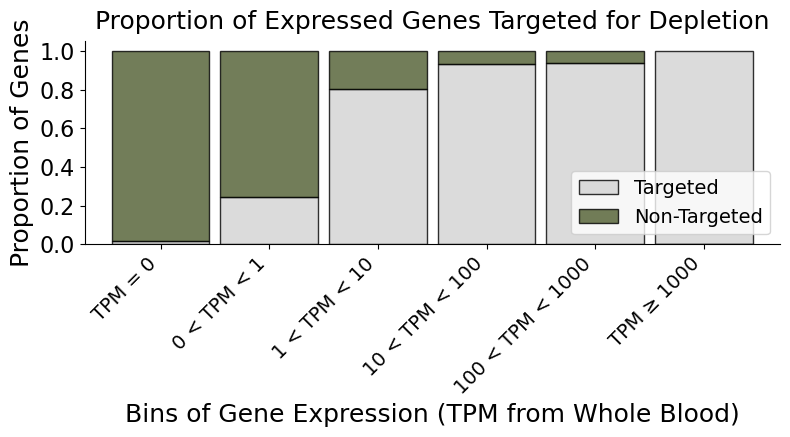

In [348]:
control.groupby('Standard_Bins')['Condition'].value_counts().unstack().fillna(0)
#convert to a proportion table
enriched = control.groupby('Standard_Bins')['Condition'].value_counts().unstack().fillna(0)
enriched['proportion_depleted'] = enriched['Depleted']/(enriched['Depleted']+enriched['Enriched'])
enriched['proportion_enriched'] = enriched['Enriched']/(enriched['Depleted']+enriched['Enriched'])
#sort by proportion depleted
enriched = enriched.sort_values(by='proportion_depleted', ascending=True)
enriched = enriched.reset_index()
enriched = enriched.drop(columns=['Depleted','Enriched'])

ax = enriched.plot.bar(x='Standard_Bins', stacked=True, color=['lightgrey', '#4F5D2F'], figsize=(8,4.5),
                      rot=45, legend='right', xlabel="", fontsize=16, width=0.9, alpha=0.8, edgecolor='black')
ax.set_title('Proportion of Expressed Genes Targeted for Depletion', fontsize=18, y=1.02)
ax.set_ylabel('Proportion of Genes',fontsize=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.set_xticks(ax.get_xticks(), labels=enriched['Standard_Bins'], fontsize=14)
ax.legend([ 'Targeted', 'Non-Targeted',], loc='lower right', fontsize=14)
sns.despine()
plt.xlabel('Bins of Gene Expression (TPM from Whole Blood)', fontsize=18)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_proportion_targeted_genes_depleted_per_TPM_bin.png', dpi=300)
plt.show()

See where the targeted contigs overlap annotation features 
-
What about other genomic annotation features - this is in relation to all genomic features

In [349]:
standard = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Preserved_homer_anno_stats.txt', sep='\t', header=0)
standard = standard[~standard['Annotation'].isin(['miRNA','snoRNA','scRNA','rRNA'])]
standard

,Annotation,Number of peaks,Total size (bp),Log2 Ratio (obs/exp),LogP enrichment (+values depleted)
0,3UTR,7074.0,26833139,0.823,-975.292
2,ncRNA,2181.0,7044070,1.055,-469.204
3,TTS,8418.0,32404629,0.802,-1108.270
4,pseudo,1159.0,2111155,1.881,-671.910
5,Exon,26677.0,37120946,2.270,-21332.849
6,Intron,293251.0,1257910936,0.646,-49331.795
7,Intergenic,108555.0,1684358172,-1.209,91662.597
8,Promoter,10717.0,35946139,1.001,-2108.792
9,5UTR,1852.0,2601483,2.256,-1438.837


In [350]:
depleted = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/Targeted_homer_anno_stats.txt', sep='\t', header=0)
depleted = depleted[~depleted['Annotation'].isin(['miRNA','snoRNA','scRNA','rRNA'])]
depleted

,Annotation,Number of peaks,Total size (bp),Log2 Ratio (obs/exp),LogP enrichment (+values depleted)
0,3UTR,3468.0,26833139,2.674,-3577.517
2,ncRNA,268.0,7044597,0.909,-46.699
3,TTS,1358.0,32407530,1.049,-293.477
4,pseudo,187.0,2111155,2.129,-135.112
5,Exon,7286.0,37120946,3.276,-10376.721
6,Intron,44629.0,1257910936,0.809,-12000.238
7,Intergenic,2896.0,1684360386,-3.558,37079.705
8,Promoter,1988.0,35948263,1.449,-754.016
9,5UTR,429.0,2601483,3.025,-528.231


In [351]:
counts = pd.DataFrame()
counts['Annotation'] = standard['Annotation']
counts['Standard_counts'] = standard['Number of peaks']
counts = counts.set_index('Annotation')
counts['Depleted_counts'] = depleted.set_index('Annotation')['Number of peaks']
counts = counts.fillna(0)
counts['proportion_depleted'] = counts['Depleted_counts']/(counts['Standard_counts']+counts['Depleted_counts'])
counts['proportion_standard'] = counts['Standard_counts']/(counts['Standard_counts']+counts['Depleted_counts'])
counts = counts.sort_values(by='proportion_depleted', ascending=True)
counts = counts.reset_index()
counts = counts.drop(columns=['Standard_counts','Depleted_counts'])
counts['Annotation'] = counts['Annotation'].str.replace('pseudo', 'Pseudogene')
counts

,Annotation,proportion_depleted,proportion_standard
0,Intergenic,0.025985,0.974015
1,ncRNA,0.109432,0.890568
2,Intron,0.132085,0.867915
3,TTS,0.138912,0.861088
4,Pseudogene,0.138930,0.861070
5,Promoter,0.156474,0.843526
6,5UTR,0.188075,0.811925
7,Exon,0.214528,0.785472
8,3UTR,0.328970,0.671030


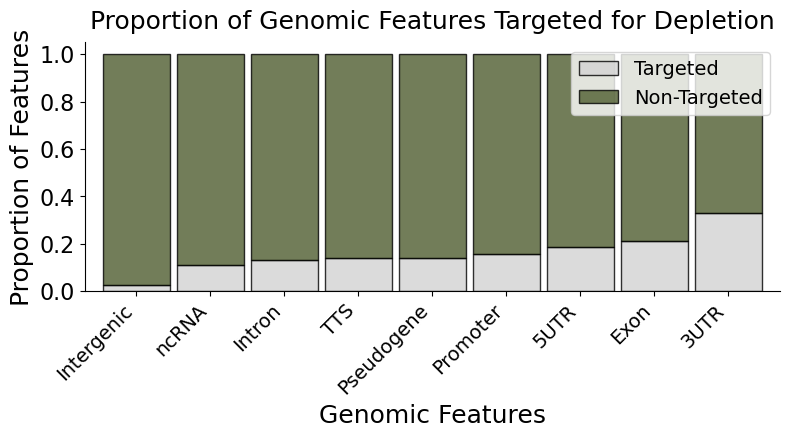

In [352]:
ax = counts.plot.bar(x='Annotation', stacked=True, color=['lightgrey', '#4F5D2F'], figsize=(8,4.5),
                      rot=45, legend='right', xlabel="", fontsize=16, width=0.9, alpha=0.8, edgecolor='black')
ax.set_title('Proportion of Genomic Features Targeted for Depletion', fontsize=18, y=1.02)
ax.set_ylabel('Proportion of Features',fontsize=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.set_xticks(ax.get_xticks(), labels=counts['Annotation'], fontsize=14)
ax.legend([ 'Targeted', 'Non-Targeted',], loc='upper right', fontsize=14)
sns.despine()
plt.xlabel('Genomic Features', fontsize=18)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_proportion_homer_anno_targeted.png', dpi=300)
plt.show()